Prueba

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
from keras.models import Sequential
from keras.layers import Dense, Dropout, GRU, InputLayer, Flatten, LSTM
from keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
import os
from datetime import datetime, timedelta
import plotly.express as px
import plotly.graph_objects as go
import random


LEER DATASET

In [2]:
import pandas as pd

datos = pd.read_csv("C:\\Users\\wamt1\\Desktop\\pruebas_collab\\SNpollutionFinal.csv")

datos['date'] = pd.to_datetime(datos['date'])

# Se establece la columna date como index
datos.set_index('date', inplace=True)


In [3]:
datos.head()

,pollution,dew,temp,press,wnd_dir,wnd_spd
date,,,,,,
2010-01-01 00:00:00,129.0,-21,-11.0,1021.0,2,1.79
2010-01-01 01:00:00,129.0,-21,-12.0,1020.0,2,4.92
2010-01-01 02:00:00,129.0,-21,-11.0,1019.0,2,6.71
2010-01-01 03:00:00,129.0,-21,-14.0,1019.0,2,9.84
2010-01-01 04:00:00,129.0,-20,-12.0,1018.0,2,12.97


In [4]:
datos = datos.drop(datos.index[:24])

datos

,pollution,dew,temp,press,wnd_dir,wnd_spd
date,,,,,,
2010-01-02 00:00:00,129.0,-16,-4.0,1020.0,1,1.79
2010-01-02 01:00:00,148.0,-15,-4.0,1020.0,1,2.68
2010-01-02 02:00:00,159.0,-11,-5.0,1021.0,1,3.57
2010-01-02 03:00:00,181.0,-7,-5.0,1022.0,1,5.36
2010-01-02 04:00:00,138.0,-7,-5.0,1022.0,1,6.25
...,...,...,...,...,...,...
2014-12-31 19:00:00,8.0,-23,-2.0,1034.0,2,231.97
2014-12-31 20:00:00,10.0,-22,-3.0,1034.0,2,237.78
2014-12-31 21:00:00,10.0,-22,-3.0,1034.0,2,242.70


In [5]:
#Se verifica que el index está en formato de dato "datetime64"
print("El index del dataframe input es un tipo de dato: ", datos.index.dtype)


El index del dataframe input es un tipo de dato:  datetime64[ns]


Se divide el dataset

In [6]:
# Dividir el conjunto de datos en entrenamiento y prueba
train, test = train_test_split(datos, test_size=0.3, shuffle=False)

# Luego, dividir el conjunto de prueba en conjuntos de prueba y validación
test, val = train_test_split(test, test_size=0.33, shuffle=False)

print("Las dimensiones de train son: ", train.shape)
print("Las dimensiones de test son: ", test.shape)
print("Las dimensiones de val son: ", val.shape)



Las dimensiones de train son:  (30660, 6)
Las dimensiones de test son:  (8803, 6)
Las dimensiones de val son:  (4337, 6)


Se normalizan los datos

In [7]:
from sklearn.preprocessing import StandardScaler


# Normalizar solo con los datos de entrenamiento
scaler = StandardScaler()
train = scaler.fit_transform(train)

# Aplicar la transformación a test y val usando los parámetros de train
test = scaler.transform(test)
val = scaler.transform(val)

train = pd.DataFrame(train, columns=datos.columns)
test = pd.DataFrame(test, columns=datos.columns)
val = pd.DataFrame(val, columns=datos.columns)


Se unen los datos nuevamente, ahora normalizados, en un único conjunto.

In [8]:
datosNormalizados = pd.concat([train, test, val])

datosNormalizados.index = datos.index


In [9]:
datosNormalizados.shape

(43800, 6)

In [10]:
datosNormalizados.head(13)


,pollution,dew,temp,press,wnd_dir,wnd_spd
date,,,,,,
2010-01-02 00:00:00,0.317681,-1.214023,-1.268524,0.329687,-0.380944,-0.464048
2010-01-02 01:00:00,0.526152,-1.144302,-1.268524,0.329687,-0.380944,-0.446575
2010-01-02 02:00:00,0.646846,-0.865419,-1.349314,0.426127,-0.380944,-0.429103
2010-01-02 03:00:00,0.888234,-0.586536,-1.349314,0.522567,-0.380944,-0.393962
2010-01-02 04:00:00,0.416431,-0.586536,-1.349314,0.522567,-0.380944,-0.376489
2010-01-02 05:00:00,0.098238,-0.586536,-1.430104,0.522567,-0.380944,-0.359017
2010-01-02 06:00:00,0.054349,-0.586536,-1.430104,0.619008,-0.380944,-0.323876
2010-01-02 07:00:00,0.262820,-0.586536,-1.349314,0.715448,-0.380944,-0.288735
2010-01-02 08:00:00,0.218931,-0.656257,-1.430104,0.715448,-0.380944,-0.253594


Se establece el formato de datos de entrada para redes GRU y LSTM, es decir [observaciones, retardos, caracteristicas]

In [11]:
futuros = 1
pasados  = 12

In [12]:
datosX = []
datosY = []
for i in range(pasados, len(datosNormalizados) - futuros + 1):
  datosX.append(datosNormalizados.iloc[i-pasados:i, 0:datosNormalizados.shape[1]])
  datosY.append(datosNormalizados.iloc[i+futuros-1:i+futuros, 0])


In [13]:
# Convertir las listas en arrays numpy
datosX = np.array(datosX)
datosY = np.array(datosY)

# Ver las dimensiones (shape) de los arrays
print("Dimensiones de X:", datosX.shape)  # (n_muestras, pasos_de_tiempo, n_características)
print("Dimensiones de Y:", datosY.shape)  # (n_muestras, n_características)

Dimensiones de X: (43788, 12, 6)
Dimensiones de Y: (43788, 1)


In [14]:
inputs = datosX.shape[1] * datosX.shape[2]
datosMLPX = datosX.reshape(datosX.shape[0], inputs)

In [15]:
print(datosX[0])
print(datosMLPX[0])

[[ 0.31768099 -1.2140229  -1.26852411  0.32968671 -0.38094383 -0.46404777]
 [ 0.52615226 -1.14430217 -1.26852411  0.32968671 -0.38094383 -0.44657536]
 [ 0.64684616 -0.86541928 -1.34931411  0.42612698 -0.38094383 -0.42910295]
 [ 0.88823396 -0.58653639 -1.34931411  0.52256725 -0.38094383 -0.39396181]
 [ 0.41643054 -0.58653639 -1.34931411  0.52256725 -0.38094383 -0.3764894 ]
 [ 0.09823754 -0.58653639 -1.4301041   0.52256725 -0.38094383 -0.35901698]
 [ 0.05434885 -0.58653639 -1.4301041   0.61900753 -0.38094383 -0.32387584]
 [ 0.26282012 -0.58653639 -1.34931411  0.7154478  -0.38094383 -0.2887347 ]
 [ 0.21893143 -0.65625711 -1.4301041   0.7154478  -0.38094383 -0.25359356]
 [ 0.3505975  -0.58653639 -1.34931411  0.81188808 -0.38094383 -0.21845241]
 [ 0.43837488 -0.58653639 -1.34931411  0.90832835 -0.38094383 -0.15700449]
 [ 0.57004095 -0.65625711 -1.34931411  0.90832835 -0.38094383 -0.09555657]]
[ 0.31768099 -1.2140229  -1.26852411  0.32968671 -0.38094383 -0.46404777
  0.52615226 -1.14430217 -

Se dividen nuevamente los conjuntos de datos

In [ ]:
from sklearn.model_selection import train_test_split

# Dividir el conjunto de datos en entrenamiento y prueba
trainX, testX = train_test_split(datosX, test_size=0.3, shuffle=False)

# Luego, dividir el conjunto de prueba en conjuntos de prueba y validación
testX, valX = train_test_split(testX, test_size=0.33, shuffle=False)

print("Las dimensiones de trainX son: ", trainX.shape)
print("Las dimensiones de testX son: ", testX.shape)
print("Las dimensiones de valX son: ", valX.shape)


Las dimensiones de trainX son:  (30651, 12, 6)
Las dimensiones de testX son:  (8801, 12, 6)
Las dimensiones de valX son:  (4336, 12, 6)


In [17]:
from sklearn.model_selection import train_test_split

# Dividir el conjunto de datos en entrenamiento y prueba
trainMLPX, testMLPX = train_test_split(datosMLPX, test_size=0.3, shuffle=False)

# Luego, dividir el conjunto de prueba en conjuntos de prueba y validación
testMLPX, valMLPX = train_test_split(testMLPX, test_size=0.33, shuffle=False)

print("Las dimensiones de trainMLPX son: ", trainMLPX.shape)
print("Las dimensiones de testMLPX son: ", testMLPX.shape)
print("Las dimensiones de valMLPX son: ", valMLPX.shape)

Las dimensiones de trainMLPX son:  (30651, 72)
Las dimensiones de testMLPX son:  (8801, 72)
Las dimensiones de valMLPX son:  (4336, 72)


In [18]:
from sklearn.model_selection import train_test_split

# Dividir el conjunto de datos en entrenamiento y prueba
trainY, testY = train_test_split(datosY, test_size=0.3, shuffle=False)

# Luego, dividir el conjunto de prueba en conjuntos de prueba y validación
testY, valY = train_test_split(testY, test_size=0.33, shuffle=False)

print("Las dimensiones de trainY son: ", trainY.shape)
print("Las dimensiones de testY son: ", testY.shape)
print("Las dimensiones de valY son: ", valY.shape)

Las dimensiones de trainY son:  (30651, 1)
Las dimensiones de testY son:  (8801, 1)
Las dimensiones de valY son:  (4336, 1)


Se crean métricas para medir desempeño

In [19]:
import tensorflow.keras.backend as K

def smape(y_true, y_pred):
    """
    Define la función SMAPE (Error Porcentual Absoluto Medio Simétrico).
    """
    summ = K.abs(y_true) + K.abs(y_pred)
    smape_val = K.abs(y_pred - y_true) / summ * 2.0
    return K.mean(smape_val, axis=-1)

def rmse(y_true, y_pred):
    return K.sqrt(K.mean(K.square(y_pred - y_true)))

def ia(y_true, y_pred):
    numerator = K.sum(K.abs(y_true - y_pred))
    denominator = K.sum(K.abs(y_true - K.mean(y_true)) + K.abs(y_pred - K.mean(y_true)))
    return 1 - (numerator / denominator)

In [20]:
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import mean_absolute_error as mae

def graficarPrediccion(modelo, x, y, inicio, final):
  predicciones = modelo.predict(x)
  predicciones = predicciones.flatten()
  df = pd.DataFrame({'Originales': y, 'Predichos': predicciones})
  plt.plot(df.index, df['Originales'][inicio:final], label='Originales')
  plt.plot(df.index, df['Predichos'][inicio:final], label='Predichos')
  return df, mse(y, predicciones),  mae(y, predicciones), rmse(y, predicciones), smape(y,predicciones), ia(y, predicciones)

Se define el index del conjunto de validación para utilizarlo posteriormente para graficar.

In [21]:
# Fecha y hora de término del conjunto de datos de prueba
end_date = datosNormalizados.index[-1]
n_observations = valY.shape[0]  # Cambia esto al número de observaciones en tu conjunto de prueba

# Calcular la fecha y hora de inicio
start_date = end_date - timedelta(hours=(n_observations - 1))

# Crear la serie de fechas y horas
val_date = pd.date_range(start=start_date, end=end_date, freq='1H')

val_date

C:\Users\wamt1\AppData\Local\Temp\ipykernel_16040\3958427235.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  val_date = pd.date_range(start=start_date, end=end_date, freq='1H')


DatetimeIndex(['2014-07-04 08:00:00', '2014-07-04 09:00:00',
               '2014-07-04 10:00:00', '2014-07-04 11:00:00',
               '2014-07-04 12:00:00', '2014-07-04 13:00:00',
               '2014-07-04 14:00:00', '2014-07-04 15:00:00',
               '2014-07-04 16:00:00', '2014-07-04 17:00:00',
               ...
               '2014-12-31 14:00:00', '2014-12-31 15:00:00',
               '2014-12-31 16:00:00', '2014-12-31 17:00:00',
               '2014-12-31 18:00:00', '2014-12-31 19:00:00',
               '2014-12-31 20:00:00', '2014-12-31 21:00:00',
               '2014-12-31 22:00:00', '2014-12-31 23:00:00'],
              dtype='datetime64[ns]', length=4336, freq='h')

Se guardan los índices de las observaciones a utilizar para predecir

In [22]:
indices = []
for i in range(pasados, len(datosNormalizados) - futuros + 1):
  indices.append(datosNormalizados.index[i+futuros-1])

# Modelos


## MLP

In [23]:
'''
space = {
    'layers': hp.quniform('layers', 1, 4, 1),  # Cantidad de capas GRU (1, 2, 3, 4)
    'units': hp.choice('units', [8, 16, 32, 64, 128]),  # Número de unidades GRU
    'activation': hp.choice('activation', ['tanh', 'sigmoid', 'relu', 'linear']),  # Funciones de activación
    'dropout': hp.quniform('dropout', 0, 0.5, 0.1),  # Dropout entre 0 y 0.5, con pasos de 0.1
    'learning_rate': hp.loguniform('learning_rate', np.log(0.000001), np.log(0.01)),  # Tasa de aprendizaje logarítmica
    'epochs': hp.choice('epochs', [8, 16, 32, 64, 128, 256]),  # Número de épocas de entrenamiento
    'batch': hp.choice('batch', [8, 16, 32, 64, 128, 256])  # Tamaño de batch
}
'''

"\nspace = {\n    'layers': hp.quniform('layers', 1, 4, 1),  # Cantidad de capas GRU (1, 2, 3, 4)\n    'units': hp.choice('units', [8, 16, 32, 64, 128]),  # Número de unidades GRU\n    'activation': hp.choice('activation', ['tanh', 'sigmoid', 'relu', 'linear']),  # Funciones de activación\n    'dropout': hp.quniform('dropout', 0, 0.5, 0.1),  # Dropout entre 0 y 0.5, con pasos de 0.1\n    'learning_rate': hp.loguniform('learning_rate', np.log(0.000001), np.log(0.01)),  # Tasa de aprendizaje logarítmica\n    'epochs': hp.choice('epochs', [8, 16, 32, 64, 128, 256]),  # Número de épocas de entrenamiento\n    'batch': hp.choice('batch', [8, 16, 32, 64, 128, 256])  # Tamaño de batch\n}\n"

In [24]:
modelMLP = Sequential()
modelMLP.add(InputLayer(input_shape=(trainMLPX.shape[1],)))

modelMLP.add(Dense(units=128, activation="sigmoid"))
modelMLP.add(Dropout(0.1))

modelMLP.add(Dense(1))

opt = Adam(learning_rate=0.0001524958564276629)

modelMLP.compile(optimizer=opt, loss='mse', metrics=["mae", smape, rmse, ia])

modelMLP.summary()








c:\Users\wamt1\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\input_layer.py:26: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         9,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,473 (37.00 KB)

 Trainable params: 9,473 (37.00 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
np.random.seed(42)
random.seed(42)

tf.random.set_seed(42)


early_stopping = EarlyStopping(monitor='val_loss', patience=15, verbose=1, restore_best_weights= True)

historyMLP = modelMLP.fit(trainMLPX, trainY, epochs=128, validation_data=(testMLPX, testY), verbose = 2, batch_size=32, callbacks=[early_stopping])

prediccionMLP = modelMLP.predict(valMLPX)


Epoch 1/128
958/958 - 5s - 5ms/step - ia: 0.6944 - loss: 0.3316 - mae: 0.4007 - rmse: 0.5478 - smape: 0.8156 - val_ia: 0.6459 - val_loss: 0.1303 - val_mae: 0.2259 - val_rmse: 0.3015 - val_smape: 0.5236
Epoch 2/128
958/958 - 2s - 2ms/step - ia: 0.7876 - loss: 0.1831 - mae: 0.3009 - rmse: 0.4139 - smape: 0.6480 - val_ia: 0.6951 - val_loss: 0.0983 - val_mae: 0.1936 - val_rmse: 0.2646 - val_smape: 0.4621
Epoch 3/128
958/958 - 2s - 2ms/step - ia: 0.8073 - loss: 0.1542 - mae: 0.2751 - rmse: 0.3789 - smape: 0.6020 - val_ia: 0.7150 - val_loss: 0.0845 - val_mae: 0.1772 - val_rmse: 0.2466 - val_smape: 0.4352
Epoch 4/128
958/958 - 2s - 2ms/step - ia: 0.8202 - loss: 0.1353 - mae: 0.2575 - rmse: 0.3549 - smape: 0.5716 - val_ia: 0.7396 - val_loss: 0.0754 - val_mae: 0.1614 - val_rmse: 0.2291 - val_smape: 0.4024
Epoch 5/128
958/958 - 2s - 2ms/step - ia: 0.8290 - loss: 0.1250 - mae: 0.2450 - rmse: 0.3399 - smape: 0.5504 - val_ia: 0.7420 - val_loss: 0.0727 - val_mae: 0.1596 - val_rmse: 0.2267 - val_smap

In [26]:
metricasMLP = modelMLP.evaluate(valMLPX, valY, verbose=2)
print(f"Métricas en el conjunto de validación: {metricasMLP}")

136/136 - 0s - 2ms/step - ia: 0.7605 - loss: 0.0393 - mae: 0.1230 - rmse: 0.1752 - smape: 0.3305
Métricas en el conjunto de validación: [0.0392821803689003, 0.1230345293879509, 0.3304614722728729, 0.1752091348171234, 0.7605084180831909]


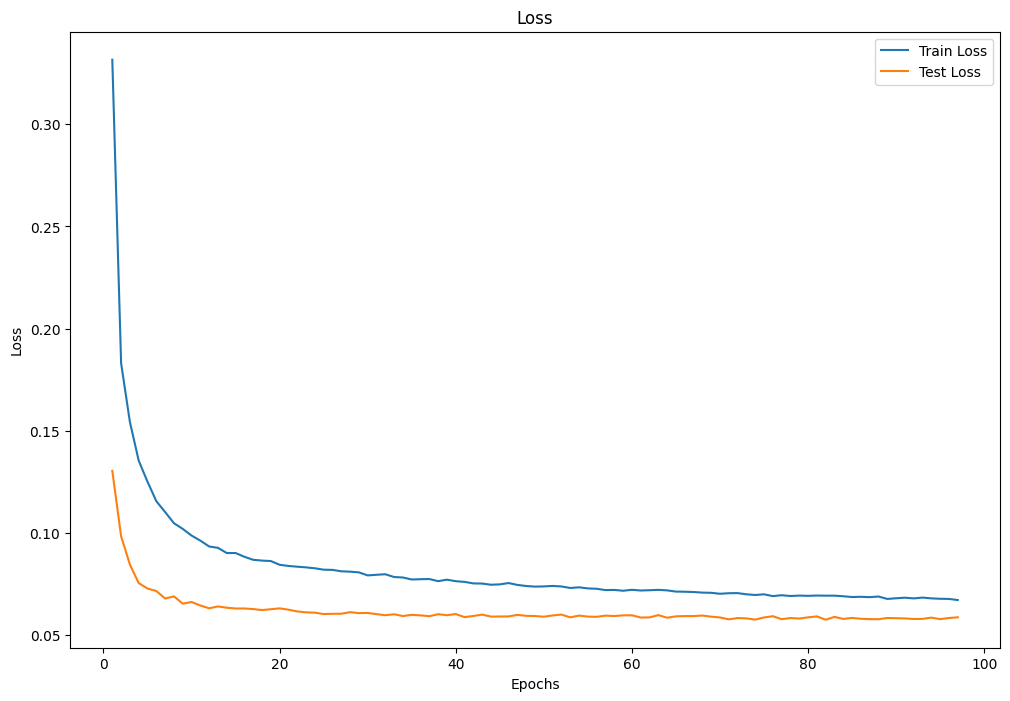

In [27]:
historyMLP = historyMLP.history
ejeXMLP = range(1, len(historyMLP['loss']) + 1)
plt.figure(figsize=(12, 8))
plt.plot(ejeXMLP, historyMLP['loss'], label='Train Loss')
plt.plot(ejeXMLP, historyMLP['val_loss'], label='Test Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [28]:
# Obtener el último valor de la pérdida de entrenamiento
ultimo_train_loss = historyMLP['loss'][-1]

# Obtener el último valor de la pérdida de validación
ultimo_val_loss = historyMLP['val_loss'][-1]

# Imprimir los valores finales
print(f'Último valor de Train Loss: {ultimo_train_loss}')
print(f'Último valor de Test Loss: {ultimo_val_loss}')

Último valor de Train Loss: 0.06711418181657791
Último valor de Test Loss: 0.05864086002111435


In [ ]:
# Crea un DataFrame con los datos originales y los predichos
df = pd.DataFrame({'Originales': valY.flatten(), 'Predichos': prediccionMLP.flatten()})
df.index = val_date

fecha_inicio = df.index[0]
fecha_fin = df.index[-1]


fig = px.line(df, title='Valores Originales vs Valores Predichos')
fig.update_xaxes(rangeslider_visible=True, title='Índice de la Muestra', range=[fecha_inicio, fecha_fin])
fig.update_yaxes(title='Valores')


fig.add_trace(go.Scatter(x=df.index, y=[0] * len(df), mode='lines', name='Igualdad', line=dict(color='black', dash='dash')))
dfMLP = df
fig.show()

### Datos para NARMAX

In [30]:
prediccionNarmaxMLP = modelMLP.predict(datosMLPX)
erroresMLP = datosY - prediccionNarmaxMLP 

1369/1369 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


In [31]:
dfErroresMLP = pd.DataFrame(erroresMLP, columns = ["e"])
dfErroresMLP.index = indices

In [32]:
dfNarmaxMLP = datosNormalizados.join(dfErroresMLP, how = 'left')

print(dfNarmaxMLP.head())
print(dfNarmaxMLP.tail())

                     pollution       dew      temp     press   wnd_dir  \
date                                                                     
2010-01-02 00:00:00   0.317681 -1.214023 -1.268524  0.329687 -0.380944   
2010-01-02 01:00:00   0.526152 -1.144302 -1.268524  0.329687 -0.380944   
2010-01-02 02:00:00   0.646846 -0.865419 -1.349314  0.426127 -0.380944   
2010-01-02 03:00:00   0.888234 -0.586536 -1.349314  0.522567 -0.380944   
2010-01-02 04:00:00   0.416431 -0.586536 -1.349314  0.522567 -0.380944   

                      wnd_spd   e  
date                               
2010-01-02 00:00:00 -0.464048 NaN  
2010-01-02 01:00:00 -0.446575 NaN  
2010-01-02 02:00:00 -0.429103 NaN  
2010-01-02 03:00:00 -0.393962 NaN  
2010-01-02 04:00:00 -0.376489 NaN  
                     pollution       dew      temp     press   wnd_dir  \
date                                                                     
2014-12-31 19:00:00  -1.009952 -1.702068 -1.106944  1.679851  0.694538   
2014-12

In [33]:
dfNarmaxMLP.to_csv('C:\\Users\\wamt1\\Desktop\\pruebas_collab\\datosNarmax\\1pasos_mlp_pollution.csv', index=True)

In [34]:
dfMLP.to_csv('C:\\Users\\wamt1\\Desktop\\pruebas_collab\\evaluacion\\1pasos_mlp_pollution.csv', index=True)

In [35]:
modelMLP.save('C:\\Users\\wamt1\\Desktop\\pruebas_collab\\modelosEntrenadosNarx\\1pasos_mlp_pollution.h5')

## LSTM

In [36]:
'''
space = {
    'layers': hp.quniform('layers', 1, 4, 1),  # Cantidad de capas GRU (1, 2, 3, 4)
    'units': hp.choice('units', [8, 16, 32, 64, 128]),  # Número de unidades GRU
    'activation': hp.choice('activation', ['tanh', 'sigmoid', 'relu', 'linear']),  # Funciones de activación
    'dropout': hp.quniform('dropout', 0, 0.5, 0.1),  # Dropout entre 0 y 0.5, con pasos de 0.1
    'learning_rate': hp.loguniform('learning_rate', np.log(0.000001), np.log(0.01)),  # Tasa de aprendizaje logarítmica
    'epochs': hp.choice('epochs', [8, 16, 32, 64, 128, 256]),  # Número de épocas de entrenamiento
    'batch': hp.choice('batch', [8, 16, 32, 64, 128, 256])  # Tamaño de batch
}
'''

"\nspace = {\n    'layers': hp.quniform('layers', 1, 4, 1),  # Cantidad de capas GRU (1, 2, 3, 4)\n    'units': hp.choice('units', [8, 16, 32, 64, 128]),  # Número de unidades GRU\n    'activation': hp.choice('activation', ['tanh', 'sigmoid', 'relu', 'linear']),  # Funciones de activación\n    'dropout': hp.quniform('dropout', 0, 0.5, 0.1),  # Dropout entre 0 y 0.5, con pasos de 0.1\n    'learning_rate': hp.loguniform('learning_rate', np.log(0.000001), np.log(0.01)),  # Tasa de aprendizaje logarítmica\n    'epochs': hp.choice('epochs', [8, 16, 32, 64, 128, 256]),  # Número de épocas de entrenamiento\n    'batch': hp.choice('batch', [8, 16, 32, 64, 128, 256])  # Tamaño de batch\n}\n"

In [37]:
modelLSTM = Sequential()
modelLSTM.add(InputLayer(input_shape=(trainX.shape[1], trainX.shape[2])))

modelLSTM.add(LSTM(units=128, activation="relu", return_sequences=False))
modelLSTM.add(Dropout(0.3))

modelLSTM.add(Dense(1))


opt = Adam(learning_rate=0.00045371747819692945)
modelLSTM.compile(optimizer=opt, loss='mse', metrics=["mae", smape, rmse, ia])

modelLSTM.summary()



c:\Users\wamt1\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\input_layer.py:26: UserWarning:

Argument `input_shape` is deprecated. Use `shape` instead.



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128)            │        69,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 69,249 (270.50 KB)

 Trainable params: 69,249 (270.50 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
np.random.seed(42)
random.seed(42)

tf.random.set_seed(42)


early_stopping = EarlyStopping(monitor='val_loss', patience=15, verbose=1, restore_best_weights= True)

historyLSTM = modelLSTM.fit(trainX, trainY, epochs=32, validation_data=(testX, testY), verbose = 2, batch_size=16, callbacks=[early_stopping])


prediccionLSTM = modelLSTM.predict(valX)

Epoch 1/32
1916/1916 - 24s - 13ms/step - ia: 0.8119 - loss: 0.1533 - mae: 0.2468 - rmse: 0.3530 - smape: 0.5505 - val_ia: 0.6347 - val_loss: 0.0714 - val_mae: 0.1582 - val_rmse: 0.2128 - val_smape: 0.4023
Epoch 2/32
1916/1916 - 16s - 8ms/step - ia: 0.8627 - loss: 0.0897 - mae: 0.1869 - rmse: 0.2720 - smape: 0.4388 - val_ia: 0.6561 - val_loss: 0.0642 - val_mae: 0.1479 - val_rmse: 0.1995 - val_smape: 0.3741
Epoch 3/32
1916/1916 - 15s - 8ms/step - ia: 0.8718 - loss: 0.0814 - mae: 0.1752 - rmse: 0.2577 - smape: 0.4150 - val_ia: 0.6643 - val_loss: 0.0618 - val_mae: 0.1442 - val_rmse: 0.1959 - val_smape: 0.3654
Epoch 4/32
1916/1916 - 15s - 8ms/step - ia: 0.8766 - loss: 0.0771 - mae: 0.1690 - rmse: 0.2501 - smape: 0.4044 - val_ia: 0.6480 - val_loss: 0.0638 - val_mae: 0.1505 - val_rmse: 0.2004 - val_smape: 0.3750
Epoch 5/32
1916/1916 - 12s - 6ms/step - ia: 0.8802 - loss: 0.0736 - mae: 0.1638 - rmse: 0.2434 - smape: 0.3922 - val_ia: 0.6552 - val_loss: 0.0596 - val_mae: 0.1452 - val_rmse: 0.1948

In [39]:
metricasLSTM = modelLSTM.evaluate(valX, valY, verbose=2)
print(f"Métricas en el conjunto de validación: {metricasLSTM}")

136/136 - 1s - 5ms/step - ia: 0.7455 - loss: 0.0390 - mae: 0.1263 - rmse: 0.1755 - smape: 0.3280
Métricas en el conjunto de validación: [0.03896820545196533, 0.12627817690372467, 0.32795843482017517, 0.17548590898513794, 0.7454871535301208]


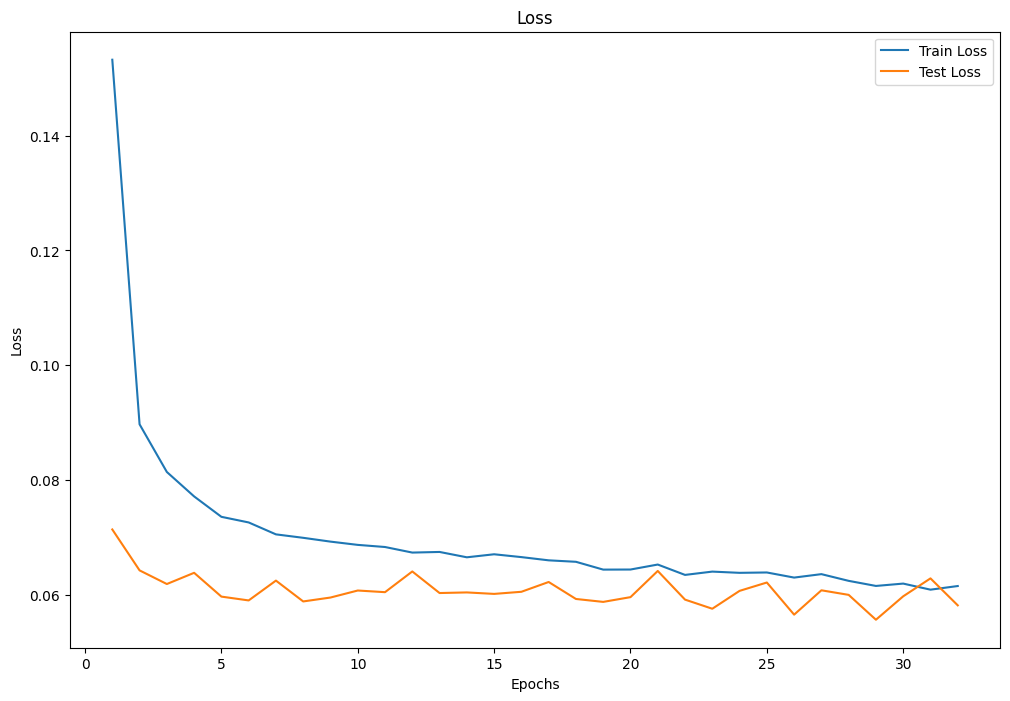

In [40]:
historyLSTM = historyLSTM.history

ejeXLSTM = range(1, len(historyLSTM['loss']) + 1)

plt.figure(figsize=(12, 8))
plt.plot(ejeXLSTM, historyLSTM['loss'], label='Train Loss')
plt.plot(ejeXLSTM, historyLSTM['val_loss'], label='Test Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()
plt.show()

In [41]:
# Obtener el último valor de la pérdida de entrenamiento
ultimo_train_loss = historyLSTM['loss'][-1]

# Obtener el último valor de la pérdida de validación
ultimo_val_loss = historyLSTM['val_loss'][-1]

# Imprimir los valores finales
print(f'Último valor de Train Loss: {ultimo_train_loss}')
print(f'Último valor de Test Loss: {ultimo_val_loss}')

Último valor de Train Loss: 0.06148651987314224
Último valor de Test Loss: 0.05811796709895134


In [ ]:
# Crea un DataFrame con los datos originales y los predichos
df = pd.DataFrame({'Originales': valY.flatten(), 'Predichos': prediccionLSTM.flatten()})
df.index = val_date

fecha_inicio = df.index[0]
fecha_fin = df.index[-1]


fig = px.line(df, title='Valores Originales vs Valores Predichos')
fig.update_xaxes(rangeslider_visible=True, title='Índice de la Muestra', range=[fecha_inicio, fecha_fin])
fig.update_yaxes(title='Valores')


fig.add_trace(go.Scatter(x=df.index, y=[0] * len(df), mode='lines', name='Igualdad', line=dict(color='black', dash='dash')))
dfLSTM = df
fig.show()


### Datos para NARMAX

In [43]:
prediccionNarmaxLSTM = modelLSTM.predict(datosX)
erroresLSTM = datosY - prediccionNarmaxLSTM 

1369/1369 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step


In [44]:
dfErroresLSTM = pd.DataFrame(erroresLSTM, columns = ["e"])
dfErroresLSTM.index = indices

In [45]:
dfNarmaxLSTM = datosNormalizados.join(dfErroresLSTM, how = 'left')

print(dfNarmaxLSTM.head())
print(dfNarmaxLSTM.tail())

                     pollution       dew      temp     press   wnd_dir  \
date                                                                     
2010-01-02 00:00:00   0.317681 -1.214023 -1.268524  0.329687 -0.380944   
2010-01-02 01:00:00   0.526152 -1.144302 -1.268524  0.329687 -0.380944   
2010-01-02 02:00:00   0.646846 -0.865419 -1.349314  0.426127 -0.380944   
2010-01-02 03:00:00   0.888234 -0.586536 -1.349314  0.522567 -0.380944   
2010-01-02 04:00:00   0.416431 -0.586536 -1.349314  0.522567 -0.380944   

                      wnd_spd   e  
date                               
2010-01-02 00:00:00 -0.464048 NaN  
2010-01-02 01:00:00 -0.446575 NaN  
2010-01-02 02:00:00 -0.429103 NaN  
2010-01-02 03:00:00 -0.393962 NaN  
2010-01-02 04:00:00 -0.376489 NaN  
                     pollution       dew      temp     press   wnd_dir  \
date                                                                     
2014-12-31 19:00:00  -1.009952 -1.702068 -1.106944  1.679851  0.694538   
2014-12

In [46]:
dfNarmaxLSTM.to_csv('C:\\Users\\wamt1\\Desktop\\pruebas_collab\\datosNarmax\\1pasos_lstm_pollution.csv', index=True)

In [47]:
dfLSTM.to_csv('C:\\Users\\wamt1\\Desktop\\pruebas_collab\\evaluacion\\1pasos_lstm_pollution.csv', index=True)

In [48]:
modelLSTM.save('C:\\Users\\wamt1\\Desktop\\pruebas_collab\\modelosEntrenadosNarx\\1pasos_lstm_pollution.h5')

## GRU

In [49]:
'''
space = {
    'layers': hp.quniform('layers', 1, 4, 1),  # Cantidad de capas GRU (1, 2, 3, 4)
    'units': hp.choice('units', [8, 16, 32, 64, 128]),  # Número de unidades GRU
    'activation': hp.choice('activation', ['tanh', 'sigmoid', 'relu', 'linear']),  # Funciones de activación
    'dropout': hp.quniform('dropout', 0, 0.5, 0.1),  # Dropout entre 0 y 0.5, con pasos de 0.1
    'learning_rate': hp.loguniform('learning_rate', np.log(0.000001), np.log(0.01)),  # Tasa de aprendizaje logarítmica
    'epochs': hp.choice('epochs', [8, 16, 32, 64, 128, 256]),  # Número de épocas de entrenamiento
    'batch': hp.choice('batch', [8, 16, 32, 64, 128, 256])  # Tamaño de batch
}
'''

"\nspace = {\n    'layers': hp.quniform('layers', 1, 4, 1),  # Cantidad de capas GRU (1, 2, 3, 4)\n    'units': hp.choice('units', [8, 16, 32, 64, 128]),  # Número de unidades GRU\n    'activation': hp.choice('activation', ['tanh', 'sigmoid', 'relu', 'linear']),  # Funciones de activación\n    'dropout': hp.quniform('dropout', 0, 0.5, 0.1),  # Dropout entre 0 y 0.5, con pasos de 0.1\n    'learning_rate': hp.loguniform('learning_rate', np.log(0.000001), np.log(0.01)),  # Tasa de aprendizaje logarítmica\n    'epochs': hp.choice('epochs', [8, 16, 32, 64, 128, 256]),  # Número de épocas de entrenamiento\n    'batch': hp.choice('batch', [8, 16, 32, 64, 128, 256])  # Tamaño de batch\n}\n"

In [50]:
modelGRU = Sequential()
modelGRU.add(InputLayer(input_shape=(trainX.shape[1], trainX.shape[2])))

modelGRU.add(GRU(units=128, activation="sigmoid", return_sequences=True))
modelGRU.add(Dropout(0.1))

modelGRU.add(GRU(units=128, activation="sigmoid", return_sequences=True))
modelGRU.add(Dropout(0.1))

modelGRU.add(GRU(units=128, activation="sigmoid", return_sequences=False))
modelGRU.add(Dropout(0.1))

modelGRU.add(Dense(1))


opt = Adam(learning_rate=0.00011887634859710345)
modelGRU.compile(optimizer=opt, loss='mse', metrics=["mae", smape, rmse, ia])

modelGRU.summary()




c:\Users\wamt1\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\input_layer.py:26: UserWarning:

Argument `input_shape` is deprecated. Use `shape` instead.



Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 12, 128)        │        52,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 12, 128)        │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 128)            │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 250,497 (978.50 KB)

 Trainable params: 250,497 (978.50 KB)

 Non-trainable params: 0 (0.00 B)

In [51]:
np.random.seed(42)
random.seed(42)

tf.random.set_seed(42)

early_stopping = EarlyStopping(monitor='val_loss', patience=15, verbose=1, restore_best_weights= True)

historyGRU = modelGRU.fit(trainX, trainY, epochs=128, validation_data=(testX, testY), verbose = 2, batch_size=16, callbacks=[early_stopping])

prediccionGRU = modelGRU.predict(valX)

Epoch 1/128
1916/1916 - 66s - 35ms/step - ia: 0.5714 - loss: 0.5076 - mae: 0.4870 - rmse: 0.6439 - smape: 1.0018 - val_ia: 0.4849 - val_loss: 0.1277 - val_mae: 0.2387 - val_rmse: 0.2965 - val_smape: 0.5604
Epoch 2/128
1916/1916 - 37s - 19ms/step - ia: 0.7946 - loss: 0.1581 - mae: 0.2747 - rmse: 0.3729 - smape: 0.6117 - val_ia: 0.5476 - val_loss: 0.0907 - val_mae: 0.1973 - val_rmse: 0.2494 - val_smape: 0.4777
Epoch 3/128
1916/1916 - 37s - 19ms/step - ia: 0.8228 - loss: 0.1238 - mae: 0.2381 - rmse: 0.3271 - smape: 0.5491 - val_ia: 0.5681 - val_loss: 0.0781 - val_mae: 0.1837 - val_rmse: 0.2347 - val_smape: 0.4531
Epoch 4/128
1916/1916 - 34s - 18ms/step - ia: 0.8375 - loss: 0.1089 - mae: 0.2187 - rmse: 0.3040 - smape: 0.5116 - val_ia: 0.5805 - val_loss: 0.0730 - val_mae: 0.1763 - val_rmse: 0.2267 - val_smape: 0.4383
Epoch 5/128
1916/1916 - 34s - 18ms/step - ia: 0.8488 - loss: 0.0981 - mae: 0.2044 - rmse: 0.2879 - smape: 0.4839 - val_ia: 0.6198 - val_loss: 0.0643 - val_mae: 0.1559 - val_rms

In [52]:
metricasGRU = modelGRU.evaluate(valX, valY, verbose=2)
print(f"Métricas en el conjunto de validación: {metricasGRU}")

136/136 - 1s - 5ms/step - ia: 0.7572 - loss: 0.0376 - mae: 0.1207 - rmse: 0.1717 - smape: 0.3207
Métricas en el conjunto de validación: [0.037640977650880814, 0.12066107243299484, 0.3207339942455292, 0.17174436151981354, 0.7572146058082581]


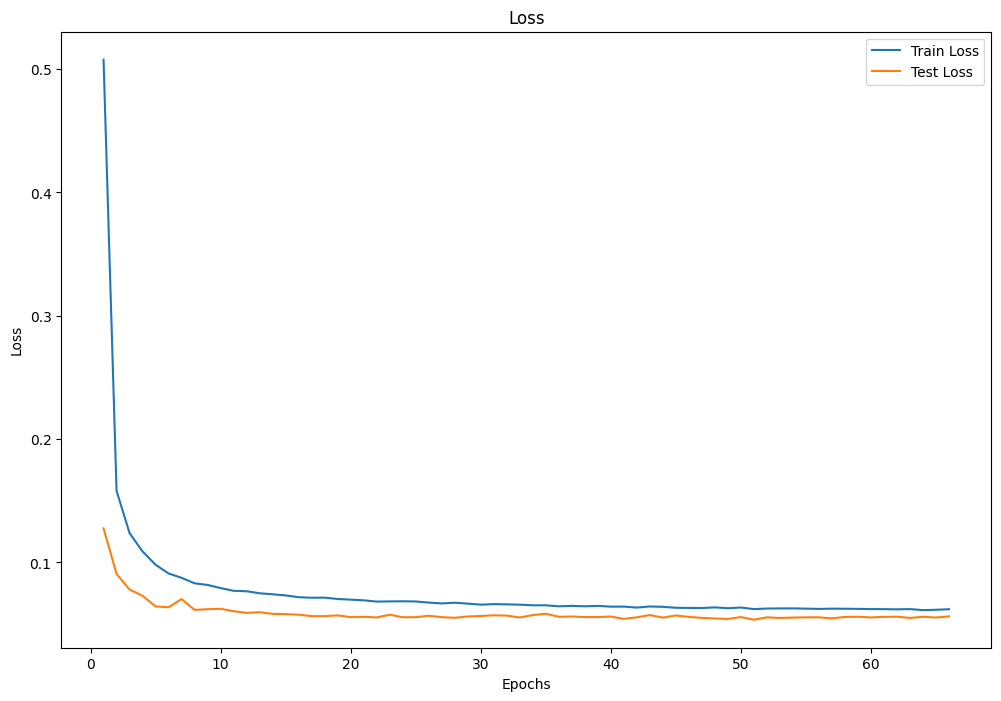

In [53]:
historyGRU = historyGRU.history
    
ejeXGRU = range(1, len(historyGRU['loss']) + 1)
plt.figure(figsize=(12, 8))
plt.plot(ejeXGRU, historyGRU['loss'], label='Train Loss')
plt.plot(ejeXGRU, historyGRU['val_loss'], label='Test Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [54]:
# Obtener el último valor de la pérdida de entrenamiento
ultimo_train_loss = historyGRU['loss'][-1]

# Obtener el último valor de la pérdida de validación
ultimo_val_loss = historyGRU['val_loss'][-1]

# Imprimir los valores finales
print(f'Último valor de Train Loss: {ultimo_train_loss}')
print(f'Último valor de Test Loss: {ultimo_val_loss}')

Último valor de Train Loss: 0.0620841346681118
Último valor de Test Loss: 0.05627629533410072


In [ ]:
# Crea un DataFrame con los datos originales y los predichos
df = pd.DataFrame({'Originales': valY.flatten(), 'Predichos': prediccionGRU.flatten()})
df.index = val_date

fecha_inicio = df.index[0]
fecha_fin = df.index[-1]


fig = px.line(df, title='Valores Originales vs Valores Predichos')
fig.update_xaxes(rangeslider_visible=True, title='Índice de la Muestra', range=[fecha_inicio, fecha_fin])
fig.update_yaxes(title='Valores')


fig.add_trace(go.Scatter(x=df.index, y=[0] * len(df), mode='lines', name='Igualdad', line=dict(color='black', dash='dash')))
dfGRU= df
fig.show()

### Datos para NARMAX

In [56]:
prediccionNarmaxGRU = modelGRU.predict(datosX)
erroresGRU = datosY - prediccionNarmaxGRU

1369/1369 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step


In [57]:
dfErroresGRU = pd.DataFrame(erroresGRU, columns = ["e"])
dfErroresGRU.index = indices

In [58]:
dfNarmaxGRU = datosNormalizados.join(dfErroresGRU, how = 'left')

print(dfNarmaxGRU.head())
print(dfNarmaxGRU.tail())

                     pollution       dew      temp     press   wnd_dir  \
date                                                                     
2010-01-02 00:00:00   0.317681 -1.214023 -1.268524  0.329687 -0.380944   
2010-01-02 01:00:00   0.526152 -1.144302 -1.268524  0.329687 -0.380944   
2010-01-02 02:00:00   0.646846 -0.865419 -1.349314  0.426127 -0.380944   
2010-01-02 03:00:00   0.888234 -0.586536 -1.349314  0.522567 -0.380944   
2010-01-02 04:00:00   0.416431 -0.586536 -1.349314  0.522567 -0.380944   

                      wnd_spd   e  
date                               
2010-01-02 00:00:00 -0.464048 NaN  
2010-01-02 01:00:00 -0.446575 NaN  
2010-01-02 02:00:00 -0.429103 NaN  
2010-01-02 03:00:00 -0.393962 NaN  
2010-01-02 04:00:00 -0.376489 NaN  
                     pollution       dew      temp     press   wnd_dir  \
date                                                                     
2014-12-31 19:00:00  -1.009952 -1.702068 -1.106944  1.679851  0.694538   
2014-12

In [59]:
dfNarmaxGRU.to_csv('C:\\Users\\wamt1\\Desktop\\pruebas_collab\\datosNarmax\\1pasos_gru_pollution.csv', index=True)

In [60]:
dfGRU.to_csv('C:\\Users\\wamt1\\Desktop\\pruebas_collab\\evaluacion\\1pasos_gru_pollution.csv', index=True)

In [61]:
modelGRU.save('C:\\Users\\wamt1\\Desktop\\pruebas_collab\\modelosEntrenadosNarx\\1pasos_gru_pollution.h5')